In [2]:
pip install catboost

In [3]:
import pandas as pd
import numpy as np

#plotting library
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Model
from catboost import CatBoostClassifier

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
dataset=pd.read_csv("rice_seed_variety.csv")

In [6]:
dataset.head()

,soil_type,sowing_month,harvest_month,water_source,soil_ph,temperature,nitrogen_N,phosphorus_P,potassium_K,seed_variety
0,Alluvial soil,Jun,Sep,irrigated,7.6,26.9,82.4,40.7,42.2,Basmati
1,Loamy soil,Jul,Oct,rainfed,6.2,35.8,90.5,51.3,46.2,IRRI-6
2,Clay soil,Jun,Sep,irrigated,6.7,34.9,86.2,50.7,44.4,IRRI-6
3,Alluvial soil,Jul,Oct,rainfed,6.1,28.3,91.3,51.3,44.5,Super Basmati
4,Loamy soil,Jun,Sep,irrigated,8.0,26.3,81.3,48.6,51.0,Basmati


In [7]:
#before dropping shape
dataset.shape

(1000, 10)

In [8]:
#checking null values

dataset.isnull().sum()

,0
soil_type,0
sowing_month,0
harvest_month,0
water_source,0
soil_ph,0
temperature,0
nitrogen_N,0
phosphorus_P,0
potassium_K,0
seed_variety,0


In [9]:
# checking duplicates
sum(dataset.duplicated())

0

In [10]:
dataset=dataset.dropna()

In [11]:
#dataset info
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   soil_type      1000 non-null   object 
 1   sowing_month   1000 non-null   object 
 2   harvest_month  1000 non-null   object 
 3   water_source   1000 non-null   object 
 4   soil_ph        1000 non-null   float64
 5   temperature    1000 non-null   float64
 6   nitrogen_N     1000 non-null   float64
 7   phosphorus_P   1000 non-null   float64
 8   potassium_K    1000 non-null   float64
 9   seed_variety   1000 non-null   object 
dtypes: float64(5), object(5)
memory usage: 78.3+ KB
None
           soil_ph  temperature  nitrogen_N  phosphorus_P  potassium_K
count  1000.000000  1000.000000  1000.00000   1000.000000  1000.000000
mean      6.468900    30.031200    89.84430     49.879400    49.912800
std       0.880055     5.645724     5.74001      5.760328     5.751908
min       5.000000    20

In [13]:
# dropping columns
dropped_columns=["harvest_month","sowing_month"]
dataset=dataset.drop(dropped_columns, axis=1)

In [14]:
#updated shape
dataset.shape

(1000, 8)

In [15]:
dataset_columns=dataset.columns
print(dataset_columns)

Index(['soil_type', 'water_source', 'soil_ph', 'temperature', 'nitrogen_N',
       'phosphorus_P', 'potassium_K', 'seed_variety'],
      dtype='object')


In [20]:
# defining columns
categorical_cols = [
    'soil_type',
    'water_source'
]

numerical_cols = [
    'soil_ph',
    'temperature',
    'nitrogen_N',
    'phosphorus_P',
    'potassium_K'

]

target_col = 'seed_variety'

In [17]:
for col in categorical_cols:
  print(dataset[col].value_counts())

soil_type
Alluvial soil    334
Loamy soil       333
Clay soil        333
Name: count, dtype: int64
water_source
irrigated    500
rainfed      500
Name: count, dtype: int64


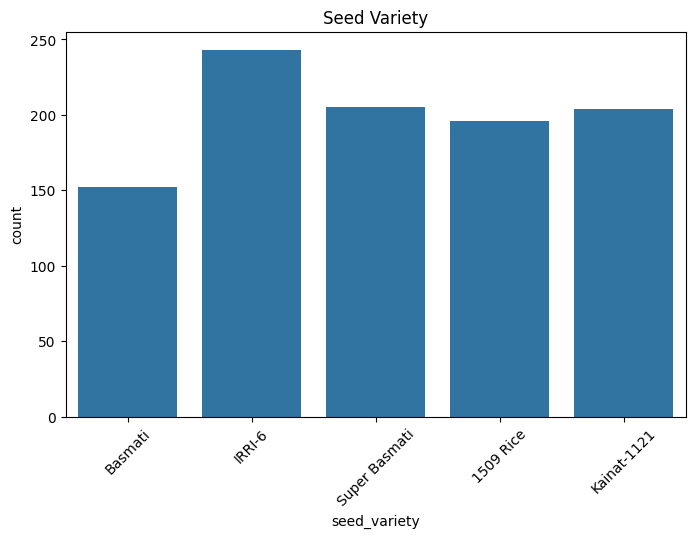

In [18]:
#plotting output columns

plt.figure(figsize=(8,5))
sns.countplot(x=dataset[target_col])
plt.title('Seed Variety')
plt.xticks(rotation=45)
plt.show()

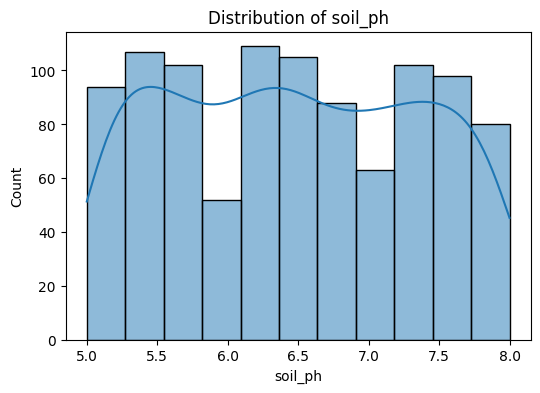

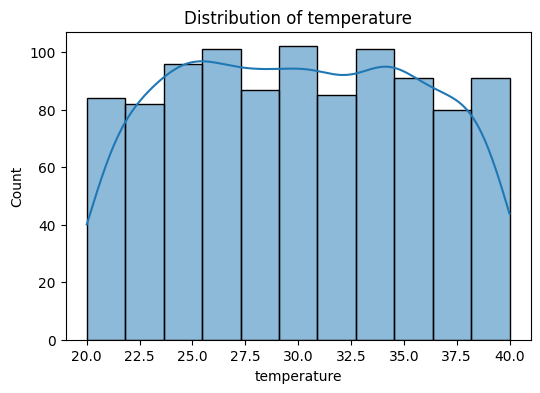

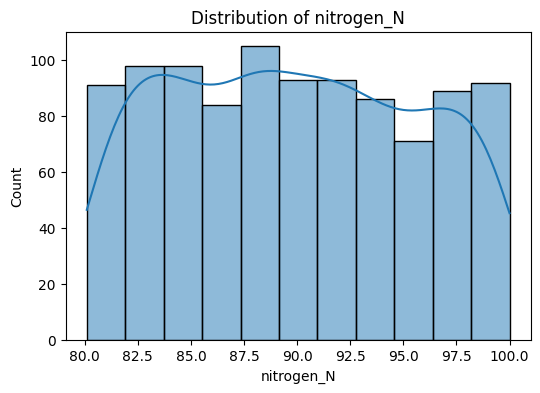

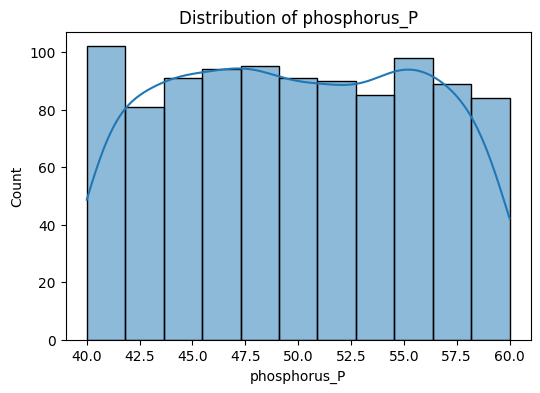

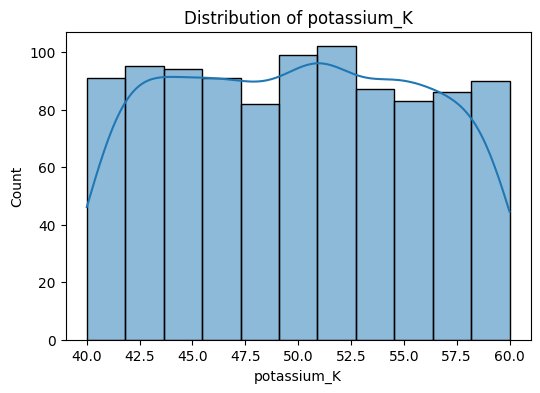

In [21]:
#checking distribution of input numerical columns

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(dataset[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

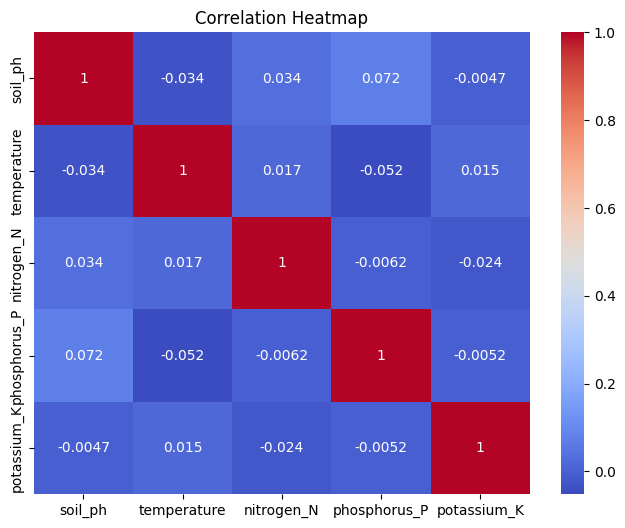

In [22]:
#checking correlation between numerical values

plt.figure(figsize=(8,6))

sns.heatmap(
    dataset[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

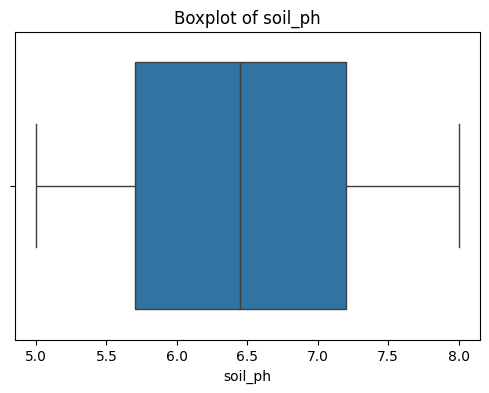

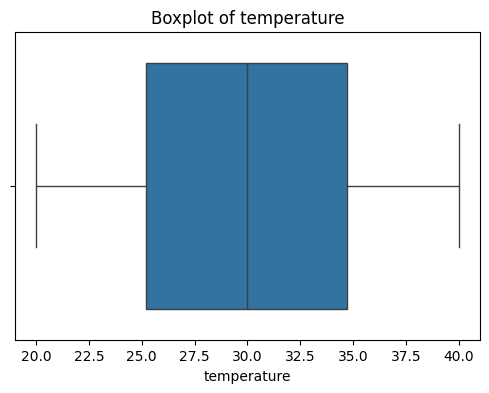

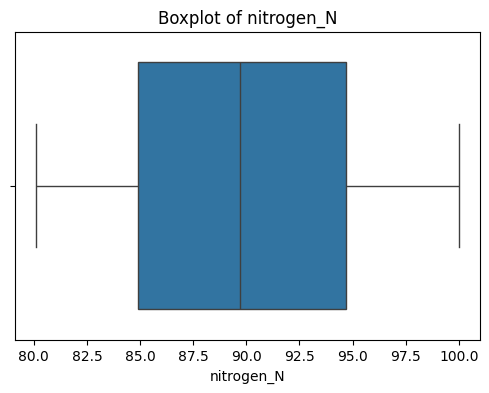

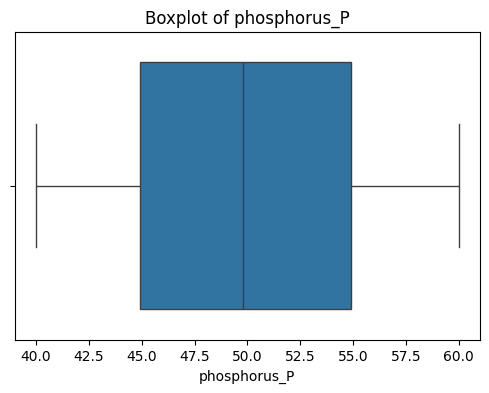

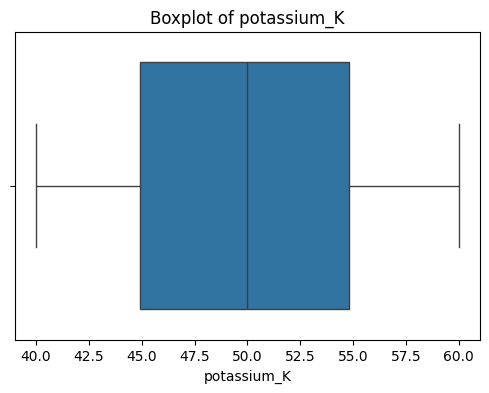

In [23]:
#plotting for outlier check
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=dataset[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [24]:
#splitting targeted and inout columns
X = dataset.drop(target_col, axis=1)
y = dataset[target_col]

In [25]:
#encoding of targeted column
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['1509 Rice' 'Basmati' 'IRRI-6' 'Kainat-1121' 'Super Basmati']


In [26]:
#splitiing before applying SMOTE technique to prevent data leak

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (800, 7)
Test Shape: (200, 7)


In [27]:


from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_encoded
)

# Convert to list
class_weights = [float(w) for w in weights]

print(class_weights)

[1.0204081632653061, 1.3157894736842106, 0.823045267489712, 0.9803921568627451, 0.975609756097561]


In [28]:

# Base model
cv_model = CatBoostClassifier(
    iterations=700,
    depth=8,
    learning_rate=0.03,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_state=42,
    verbose=100,
    l2_leaf_reg=5,
    bagging_temperature=1,
    random_strength=2
)


In [29]:
trained_model=cv_model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)


0:	learn: 0.6493738	total: 109ms	remaining: 1m 16s
100:	learn: 0.8276757	total: 2.69s	remaining: 16s
200:	learn: 0.8792009	total: 4.15s	remaining: 10.3s
300:	learn: 0.9286514	total: 6.2s	remaining: 8.22s
400:	learn: 0.9599754	total: 8.4s	remaining: 6.26s
500:	learn: 0.9712415	total: 10.5s	remaining: 4.16s
600:	learn: 0.9825168	total: 12.6s	remaining: 2.08s
699:	learn: 0.9937455	total: 15.9s	remaining: 0us


In [30]:
y_pred = trained_model.predict(X_test)

In [31]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nMacro F1 Score:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.835

Macro F1 Score:
0.8304580256465591

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.74      0.75        39
           1       0.86      0.80      0.83        30
           2       0.90      0.94      0.92        49
           3       0.89      0.83      0.86        41
           4       0.76      0.83      0.79        41

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



In [32]:
import joblib

# Save model
joblib.dump(cv_model, 'rice_seed_model.pkl')

# Save label encoder
joblib.dump(label_encoder, 'rice_seed_label_encoder.pkl')

print("Model saved successfully.")

Model saved successfully.
